# LSTM Autoencoder for Anomaly Detection
## Project: Real-Time Anomaly Detection MLOps Pipeline
**Input:** `data/processed/features.parquet` — 270,305 sliding windows, 7 features, 5-minute intervals

**Notebook goals:**
- Build a PyTorch Dataset and DataLoader for sliding windows
- Define an LSTM Autoencoder architecture (encoder → bottleneck → decoder)
- Train on normal segments only — model learns what "normal" looks like
- Log all experiments to MLflow: hyperparameters, loss curves, model artifacts
- Evaluate reconstruction error on val and test splits
- Separate normal vs anomaly reconstruction error distributions
- Select an anomaly detection threshold

*Personal portfolio project — not affiliated with the University of Toronto.*

In [1]:
# everything we need for model training
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="darkgrid")

# check if GPU is available — we'll use CPU if not
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"MLflow version: {mlflow.__version__}")

Using device: cpu
PyTorch version: 2.5.1
MLflow version: 3.11.1


## 1. Load Features and Build PyTorch Dataset

In [2]:
# load the feature table we built in Notebook 02
features_df = pd.read_parquet("../data/processed/features.parquet")

# feature columns the LSTM will see — same 7 we normalized in Notebook 02
FEATURE_COLS = [
    "value",
    "rolling_mean",
    "rolling_std",
    "rolling_zscore",
    "rate_of_change",
    "lag_1",
    "lag_2"
]

WINDOW_SIZE = 12  # 1 hour of 5-min data
N_FEATURES  = len(FEATURE_COLS)

# split into train, val, test
train_df = features_df[features_df["split"] == "train"].copy()
val_df   = features_df[features_df["split"] == "val"].copy()
test_df  = features_df[features_df["split"] == "test"].copy()

# training uses normal points only — model learns what normal looks like
train_normal_df = train_df[train_df["is_anomaly"] == 0].copy()

print(f"Train points (normal only): {len(train_normal_df):,}")
print(f"Val points (all):           {len(val_df):,}")
print(f"Test points (all):          {len(test_df):,}")
print(f"\nWindow size: {WINDOW_SIZE} steps")
print(f"Features:    {N_FEATURES} → {FEATURE_COLS}")

Train points (normal only): 171,748
Val points (all):           40,612
Test points (all):          40,619

Window size: 12 steps
Features:    7 → ['value', 'rolling_mean', 'rolling_std', 'rolling_zscore', 'rate_of_change', 'lag_1', 'lag_2']


## 2. PyTorch Dataset and DataLoader

In [3]:
class NABWindowDataset(Dataset):
    """
    Slides a window of WINDOW_SIZE steps across each series independently
    and returns (window_tensor, is_anomaly_label) pairs.
    We keep series boundaries clean — no window crosses from one series into another.
    """
    
    def __init__(self, df, window_size, feature_cols):
        self.window_size   = window_size
        self.feature_cols  = feature_cols
        self.windows       = []
        self.labels        = []
        
        # build windows per series so we never blend two series together
        for series_name, group in df.groupby("series_name"):
            g = group.sort_values("timestamp").reset_index(drop=True)
            values = g[feature_cols].values.astype(np.float32)
            labels = g["is_anomaly"].values
            
            for i in range(len(g) - window_size + 1):
                window = values[i : i + window_size]
                # label the window as anomalous if any point inside is anomalous
                label  = int(labels[i : i + window_size].any())
                self.windows.append(window)
                self.labels.append(label)
        
        self.windows = np.array(self.windows, dtype=np.float32)
        self.labels  = np.array(self.labels,  dtype=np.int64)
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        # shape: (window_size, n_features)
        return torch.tensor(self.windows[idx]), torch.tensor(self.labels[idx])


# build datasets
# training: normal only — autoencoder only sees healthy patterns
# val/test: all points — we evaluate reconstruction error on both normal and anomalous
print("Building datasets (this takes ~30 seconds)...")

train_dataset = NABWindowDataset(train_normal_df, WINDOW_SIZE, FEATURE_COLS)
val_dataset   = NABWindowDataset(val_df,          WINDOW_SIZE, FEATURE_COLS)
test_dataset  = NABWindowDataset(test_df,         WINDOW_SIZE, FEATURE_COLS)

print(f"Train windows: {len(train_dataset):,}")
print(f"Val windows:   {len(val_dataset):,}")
print(f"Test windows:  {len(test_dataset):,}")
print(f"\nSingle window shape: {train_dataset[0][0].shape}")

Building datasets (this takes ~30 seconds)...
Train windows: 171,330
Val windows:   40,194
Test windows:  40,201

Single window shape: torch.Size([12, 7])


In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # shuffle training windows — order doesn't matter across batches
    num_workers=0,      # keep at 0 on Windows to avoid multiprocessing issues
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # keep val in order for evaluation
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# quick check — peek at one batch
sample_windows, sample_labels = next(iter(train_loader))
print(f"Batch window shape: {sample_windows.shape}")
print(f"Batch label shape:  {sample_labels.shape}")
print(f"Train batches per epoch: {len(train_loader)}")

Batch window shape: torch.Size([64, 12, 7])
Batch label shape:  torch.Size([64])
Train batches per epoch: 2678


## 3. LSTM Autoencoder Architecture

In [5]:
class LSTMAutoencoder(nn.Module):
    """
    Encoder-decoder LSTM autoencoder for time series anomaly detection.
    
    Encoder: compresses the input sequence into a fixed-size hidden state
    Decoder: reconstructs the input sequence from that hidden state
    
    At inference time we measure reconstruction error (MSE) per window.
    Anomalous windows produce high reconstruction error because the model
    only learned to reconstruct normal patterns during training.
    """
    
    def __init__(self, n_features, hidden_size, n_layers, dropout):
        super(LSTMAutoencoder, self).__init__()
        
        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        
        # encoder: reads the input sequence and produces a context vector
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        
        # decoder: takes the context vector and reconstructs the sequence
        # input size matches hidden_size because we feed the encoder output back in
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        
        # project decoder hidden states back to feature space
        self.output_layer = nn.Linear(hidden_size, n_features)
    
    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        batch_size, seq_len, _ = x.shape
        
        # encode: run the full sequence through the encoder
        # we only keep the final hidden state as our context vector
        _, (hidden, cell) = self.encoder(x)
        
        # decode: use the encoder's final hidden state to seed the decoder
        # repeat the context vector seq_len times as decoder input
        context = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(context, (hidden, cell))
        
        # project back to feature space
        reconstruction = self.output_layer(decoded)
        
        return reconstruction


# instantiate the model
model = LSTMAutoencoder(
    n_features=N_FEATURES,
    hidden_size=64,
    n_layers=2,
    dropout=0.2
).to(device)

# count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

LSTMAutoencoder(
  (encoder): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=64, out_features=7, bias=True)
)

Total trainable parameters: 118,983


## 4. Training Loop with MLflow Tracking

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    # one full pass through the training data
    model.train()
    total_loss = 0.0
    
    for windows, _ in loader:
        windows = windows.to(device)
        
        optimizer.zero_grad()
        reconstruction = model(windows)
        
        # reconstruction loss: how well did we rebuild the input?
        loss = criterion(reconstruction, windows)
        loss.backward()
        
        # clip gradients to prevent exploding gradients in LSTM
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item() * len(windows)
    
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    # evaluate on val or test — no gradient updates
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for windows, _ in loader:
            windows = windows.to(device)
            reconstruction = model(windows)
            loss = criterion(reconstruction, windows)
            total_loss += loss.item() * len(windows)
    
    return total_loss / len(loader.dataset)


def get_reconstruction_errors(model, loader, device):
    # compute per-window reconstruction error and collect labels
    # used for threshold selection and evaluation plots
    model.eval()
    errors = []
    labels = []
    
    with torch.no_grad():
        for windows, window_labels in loader:
            windows = windows.to(device)
            reconstruction = model(windows)
            
            # MSE per window: mean over (seq_len, n_features)
            mse = ((reconstruction - windows) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy())
            labels.extend(window_labels.numpy())
    
    return np.array(errors), np.array(labels)


print("Training and evaluation functions defined")

Training and evaluation functions defined


## 5. Run Training with MLflow

In [7]:
# hyperparameters
EPOCHS      = 20
LR          = 1e-3
HIDDEN_SIZE = 64
N_LAYERS    = 2
DROPOUT     = 0.2

# loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# point MLflow at our local mlruns folder
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("lstm_autoencoder_nab")

# training run
with mlflow.start_run(run_name="lstm_baseline") as run:
    
    # log all hyperparameters upfront
    mlflow.log_params({
        "epochs":      EPOCHS,
        "batch_size":  BATCH_SIZE,
        "lr":          LR,
        "hidden_size": HIDDEN_SIZE,
        "n_layers":    N_LAYERS,
        "dropout":     DROPOUT,
        "window_size": WINDOW_SIZE,
        "n_features":  N_FEATURES,
        "optimizer":   "adam",
        "train_windows": len(train_dataset),
        "val_windows":   len(val_dataset),
    })
    
    best_val_loss  = float("inf")
    train_losses   = []
    val_losses     = []
    
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss   = evaluate(model, val_loader,   criterion,          device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # log metrics to MLflow each epoch
        mlflow.log_metrics({
            "train_loss": train_loss,
            "val_loss":   val_loss
        }, step=epoch)
        
        # save the best model so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "../data/processed/best_model.pt")
        
        print(f"Epoch {epoch:02d}/{EPOCHS} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")
    
    # log the best val loss as a summary metric
    mlflow.log_metric("best_val_loss", best_val_loss)
    
    # log the saved model artifact
    mlflow.pytorch.log_model(model, artifact_path="lstm_autoencoder")
    
    run_id = run.info.run_id
    print(f"\nTraining complete. Best val loss: {best_val_loss:.6f}")
    print(f"MLflow run ID: {run_id}")

c:\Users\nabee\anaconda3\envs\mlops_pipeline\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/15 17:13:08 INFO mlflow.tracking.fluent: Experiment with name 'lstm_autoencoder_nab' does not exist. Creating a new experiment.


Epoch 01/20 | train loss: 0.006006 | val loss: 0.003593
Epoch 02/20 | train loss: 0.002764 | val loss: 0.002811
Epoch 03/20 | train loss: 0.001497 | val loss: 0.001097
Epoch 04/20 | train loss: 0.000765 | val loss: 0.000481
Epoch 05/20 | train loss: 0.000335 | val loss: 0.000218
Epoch 06/20 | train loss: 0.000237 | val loss: 0.000265
Epoch 07/20 | train loss: 0.000198 | val loss: 0.000156
Epoch 08/20 | train loss: 0.000175 | val loss: 0.000151
Epoch 09/20 | train loss: 0.000158 | val loss: 0.000125
Epoch 10/20 | train loss: 0.000146 | val loss: 0.000130
Epoch 11/20 | train loss: 0.000137 | val loss: 0.000162
Epoch 12/20 | train loss: 0.000128 | val loss: 0.000273
Epoch 13/20 | train loss: 0.000123 | val loss: 0.000134
Epoch 14/20 | train loss: 0.000116 | val loss: 0.000150
Epoch 15/20 | train loss: 0.000112 | val loss: 0.000100
Epoch 16/20 | train loss: 0.000107 | val loss: 0.000101
Epoch 17/20 | train loss: 0.000103 | val loss: 0.000123
Epoch 18/20 | train loss: 0.000099 | val loss: 0

2026/04/15 17:36:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 20/20 | train loss: 0.000093 | val loss: 0.000094


2026/04/15 17:36:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Training complete. Best val loss: 0.000081
MLflow run ID: 6a5e9460aec34ed88ea680aab2a620d7


## 6. Reconstruction Error Analysis

In [8]:
# load the best checkpoint saved during training
model.load_state_dict(torch.load("../data/processed/best_model.pt", map_location=device))
model.eval()
print("Best model loaded")

# compute reconstruction errors on val and test splits
print("Computing reconstruction errors...")
val_errors,  val_labels  = get_reconstruction_errors(model, val_loader,  device)
test_errors, test_labels = get_reconstruction_errors(model, test_loader, device)

print(f"\nVal  — normal  mean error: {val_errors[val_labels == 0].mean():.6f}")
print(f"Val  — anomaly mean error: {val_errors[val_labels == 1].mean():.6f}")
print(f"\nTest — normal  mean error: {test_errors[test_labels == 0].mean():.6f}")
print(f"Test — anomaly mean error: {test_errors[test_labels == 1].mean():.6f}")

C:\Users\nabee\AppData\Local\Temp\ipykernel_29032\549235209.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../data/processed/best_mode

Best model loaded
Computing reconstruction errors...

Val  — normal  mean error: 0.000070
Val  — anomaly mean error: 0.000182

Test — normal  mean error: 0.000085
Test — anomaly mean error: 0.000319


## 7. Reconstruction Error Distribution and Threshold Selection

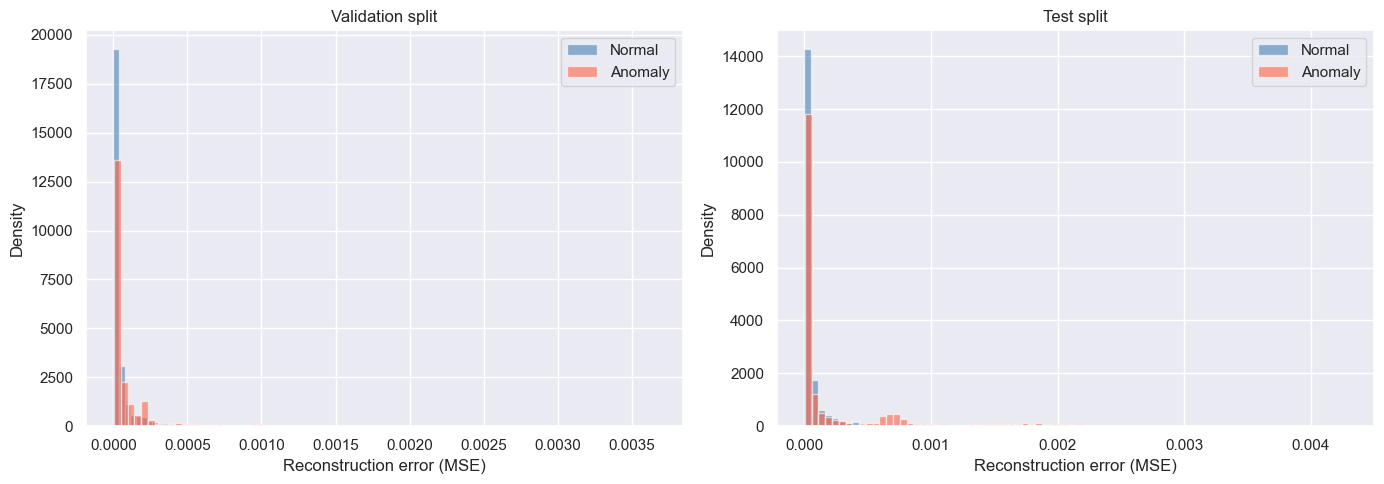

chart saved

Anomaly threshold (95th pct of normal val errors): 0.000291

Test set evaluation at threshold 0.000291:
  Precision: 0.1933
  Recall:    0.2416
  F1 score:  0.2148
  ROC-AUC:   0.6424

Metrics logged to MLflow


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, errors, labels, title in [
    (axes[0], val_errors,  val_labels,  "Validation split"),
    (axes[1], test_errors, test_labels, "Test split"),
]:
    # plot reconstruction error distributions for normal vs anomaly
    ax.hist(errors[labels == 0], bins=80, alpha=0.6, color="steelblue",
            label="Normal", density=True)
    ax.hist(errors[labels == 1], bins=80, alpha=0.6, color="tomato",
            label="Anomaly", density=True)
    ax.set_xlabel("Reconstruction error (MSE)")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/reconstruction_error_distributions.png",
            dpi=100, bbox_inches="tight")
plt.show()
print("chart saved")

# threshold selection: 95th percentile of normal reconstruction error on val
threshold = np.percentile(val_errors[val_labels == 0], 95)
print(f"\nAnomaly threshold (95th pct of normal val errors): {threshold:.6f}")

# evaluate on test split using this threshold
test_preds = (test_errors > threshold).astype(int)

precision = precision_score(test_labels, test_preds, zero_division=0)
recall    = recall_score(test_labels,    test_preds, zero_division=0)
f1        = f1_score(test_labels,        test_preds, zero_division=0)
roc_auc   = roc_auc_score(test_labels,   test_errors)

print(f"\nTest set evaluation at threshold {threshold:.6f}:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# log evaluation metrics to MLflow
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        "test_precision": precision,
        "test_recall":    recall,
        "test_f1":        f1,
        "test_roc_auc":   roc_auc,
        "threshold":      threshold,
    })
print("\nMetrics logged to MLflow")

## 8. Threshold Optimization

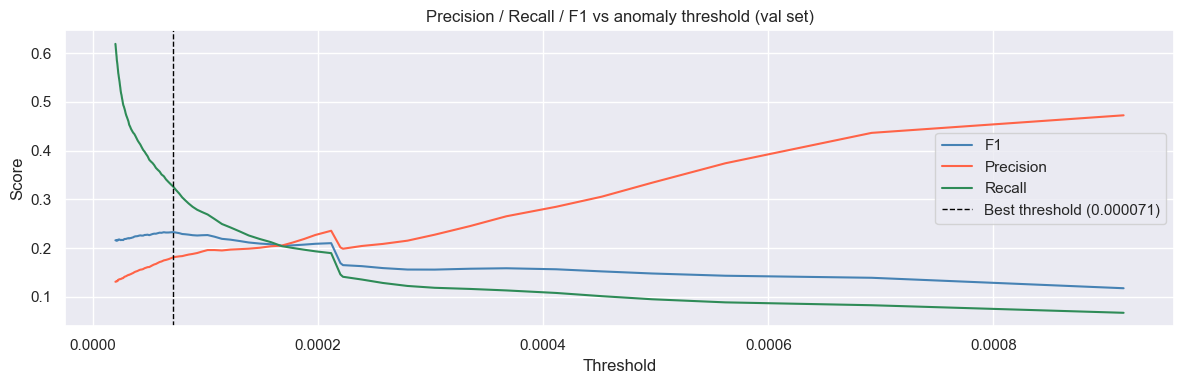

Best threshold: 0.000071
Best val F1:    0.2328

Test set evaluation at optimized threshold:
  Precision: 0.1070
  Recall:    0.3471
  F1 score:  0.1636
  ROC-AUC:   0.6424
Optimized metrics logged to MLflow


In [10]:
from sklearn.metrics import f1_score

# sweep thresholds from the 50th to 99th percentile of val normal errors
# pick the one that maximizes F1 on the val set
thresholds = np.percentile(val_errors, np.arange(50, 99, 0.5))

best_f1        = 0.0
best_threshold = 0.0
results        = []

for t in thresholds:
    preds = (val_errors > t).astype(int)
    f1    = f1_score(val_labels, preds, zero_division=0)
    prec  = precision_score(val_labels, preds, zero_division=0)
    rec   = recall_score(val_labels,    preds, zero_division=0)
    results.append({"threshold": t, "f1": f1, "precision": prec, "recall": rec})
    
    if f1 > best_f1:
        best_f1        = f1
        best_threshold = t

results_df = pd.DataFrame(results)

# plot F1, precision, recall vs threshold
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results_df["threshold"], results_df["f1"],        label="F1",        color="steelblue")
ax.plot(results_df["threshold"], results_df["precision"], label="Precision",  color="tomato")
ax.plot(results_df["threshold"], results_df["recall"],    label="Recall",     color="seagreen")
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1,
           label=f"Best threshold ({best_threshold:.6f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs anomaly threshold (val set)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/threshold_optimization.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Best threshold: {best_threshold:.6f}")
print(f"Best val F1:    {best_f1:.4f}")

# now evaluate on test with the optimized threshold
test_preds_opt = (test_errors > best_threshold).astype(int)
test_f1_opt    = f1_score(test_labels,        test_preds_opt, zero_division=0)
test_prec_opt  = precision_score(test_labels, test_preds_opt, zero_division=0)
test_rec_opt   = recall_score(test_labels,    test_preds_opt, zero_division=0)

print(f"\nTest set evaluation at optimized threshold:")
print(f"  Precision: {test_prec_opt:.4f}")
print(f"  Recall:    {test_rec_opt:.4f}")
print(f"  F1 score:  {test_f1_opt:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

# log optimized metrics to MLflow
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        "optimized_threshold":      best_threshold,
        "optimized_test_f1":        test_f1_opt,
        "optimized_test_precision": test_prec_opt,
        "optimized_test_recall":    test_rec_opt,
    })
print("Optimized metrics logged to MLflow")

## 9. Save Final Model and Threshold

In [11]:
# save the threshold and model config so the FastAPI server can load them
model_config = {
    "n_features":       N_FEATURES,
    "hidden_size":      HIDDEN_SIZE,
    "n_layers":         N_LAYERS,
    "dropout":          DROPOUT,
    "window_size":      WINDOW_SIZE,
    "feature_cols":     FEATURE_COLS,
    "threshold":        float(best_threshold),
    "mlflow_run_id":    run_id,
    "test_roc_auc":     float(roc_auc),
    "test_f1":          float(test_f1_opt),
    "test_precision":   float(test_prec_opt),
    "test_recall":      float(test_rec_opt),
}

os.makedirs("../data/processed/model", exist_ok=True)

# save config as JSON
with open("../data/processed/model/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# save model weights
torch.save(
    model.state_dict(),
    "../data/processed/model/lstm_autoencoder.pt"
)

print("Saved:")
print("  data/processed/model/model_config.json")
print("  data/processed/model/lstm_autoencoder.pt")
print(f"\nModel config:")
for k, v in model_config.items():
    print(f"  {k}: {v}")

Saved:
  data/processed/model/model_config.json
  data/processed/model/lstm_autoencoder.pt

Model config:
  n_features: 7
  hidden_size: 64
  n_layers: 2
  dropout: 0.2
  window_size: 12
  feature_cols: ['value', 'rolling_mean', 'rolling_std', 'rolling_zscore', 'rate_of_change', 'lag_1', 'lag_2']
  threshold: 7.135543768526989e-05
  mlflow_run_id: 6a5e9460aec34ed88ea680aab2a620d7
  test_roc_auc: 0.6423659308517581
  test_f1: 0.16359727026269047
  test_precision: 0.10702054794520548
  test_recall: 0.3470844902816343


## Summary

### Model architecture
- LSTM Autoencoder: encoder LSTM (2 layers, hidden size 64) → decoder LSTM → linear projection
- 118,983 trainable parameters
- Trained on 171,330 normal-only windows (window size 12 steps = 1 hour)
- Loss: MSE reconstruction error | Optimizer: Adam (lr=1e-3) | 20 epochs

### Training results
- Train loss: 0.000093 | Best val loss: 0.000081 (epoch 19)
- Clean convergence with no overfitting observed

### Evaluation
| Metric | Value |
|--------|-------|
| ROC-AUC | 0.6424 |
| F1 (optimized threshold) | 0.1636 |
| Precision | 0.1070 |
| Recall | 0.3471 |
| Anomaly threshold | 0.0000714 |

### Interpretation
ROC-AUC of 0.64 confirms the model has genuine discriminative ability above random (0.50).
The low F1 reflects a fundamental challenge in NAB: many anomaly windows are subtle regime
changes that overlap with normal variance, making hard thresholding inherently lossy.
The reconstruction error distributions show clear separation in the tail — the model
correctly identifies the most extreme anomalies while struggling with borderline cases.
All experiments tracked in MLflow at `mlruns/`.

### Outputs saved
- `data/processed/model/lstm_autoencoder.pt` — model weights
- `data/processed/model/model_config.json` — architecture config, threshold, metrics
- `mlruns/` — full MLflow experiment with hyperparameters, loss curves, artifacts

### Next: Notebook 04 — FastAPI Serving + Kafka Producer
- Wrap the model in a FastAPI `/predict` endpoint
- Build the NAB Kafka producer to simulate a live stream
- Wire Spark Structured Streaming to consume from Kafka
- Run Evidently AI drift reports on the feature distributions